In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)

In [88]:
df = pd.read_csv("seattle_filtered.csv")
df["neighbourhood_group_cleansed"].unique()

<StringArray>
['Other neighborhoods',             'Ballard',             'Cascade',
      'Rainier Valley',            'Magnolia',        'West Seattle',
          'Queen Anne',            'Downtown',        'Capitol Hill',
         'Beacon Hill',           'Lake City',        'Central Area',
 'University District',            'Delridge',           'Northgate',
         'Seward Park',            'Interbay']
Length: 17, dtype: str

In [89]:
## host_response_time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

df['host_response_time'] = df['host_response_time'].map(mapping_host_response_time)

In [90]:
# relative price
group = ["bedrooms", "bathrooms", "neighbourhood_group_cleansed", "room_type"]
df["avg_price_group"] = df.groupby(group)["price"].transform("mean")
df["relative_price"] = df["price"] / df["avg_price_group"]

In [91]:
## minimum nights -> short-term listing vs. long-term listing
threshold = 7

df['is_long_term'] = (df["minimum_nights"] > threshold).astype(int)

In [92]:
## recent_review_proportion : number_of_reviews_ltm / number_of_reviews

df["recent_review_proportion"] = df["number_of_reviews_ltm"] / df["number_of_reviews"]

In [93]:
# feature selection

cols_interested = [
    "neighbourhood_group_cleansed", # we'll run the model by neighbourhood. (not feature)
    "relative_price",
    "room_type",
    "bedrooms",
    "bathrooms",
    "beds",
    "accommodates",
    "is_long_term",
    "host_response_time",
    "host_identity_verified",
    "number_of_reviews",
    "recent_review_proportion",
    "estimated_occupancy_l365d",
    "review_scores_rating" # target variable
]

df_clean = df[cols_interested]

### West Seattle

In [94]:
# West Seattle
df_west_seattle = df_clean[df_clean["neighbourhood_group_cleansed"] == "West Seattle"]
df_west_seattle = df_west_seattle.drop(columns=["neighbourhood_group_cleansed"])

In [95]:
df_west_seattle['review_scores_rating'].describe()

count    433.000000
mean       4.659630
std        1.051678
min        0.000000
25%        4.840000
50%        4.940000
75%        4.990000
max        5.000000
Name: review_scores_rating, dtype: float64

In [96]:
## target variable (review_scores_rating) : high score (1) vs. low score (0) (threshold: 50% quartile)
threshold = 4.94

df_west_seattle['review_scores_class'] = (df_west_seattle["review_scores_rating"] > threshold).astype(int)
df_west_seattle = df_west_seattle.drop(columns=["review_scores_rating"])

In [97]:
## run RF model

X = df_west_seattle.drop(columns=["review_scores_class"])
y = df_west_seattle["review_scores_class"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [98]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5747126436781609
[[30 19]
 [18 20]]
              precision    recall  f1-score   support

           0       0.62      0.61      0.62        49
           1       0.51      0.53      0.52        38

    accuracy                           0.57        87
   macro avg       0.57      0.57      0.57        87
weighted avg       0.58      0.57      0.58        87



In [99]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

relative_price               0.204814
number_of_reviews            0.191996
recent_review_proportion     0.156460
estimated_occupancy_l365d    0.135969
accommodates                 0.069162
bathrooms                    0.052929
beds                         0.050504
bedrooms                     0.043254
host_response_time           0.035841
host_identity_verified_t     0.020664
is_long_term                 0.019339
room_type_Private room       0.019066
dtype: float64

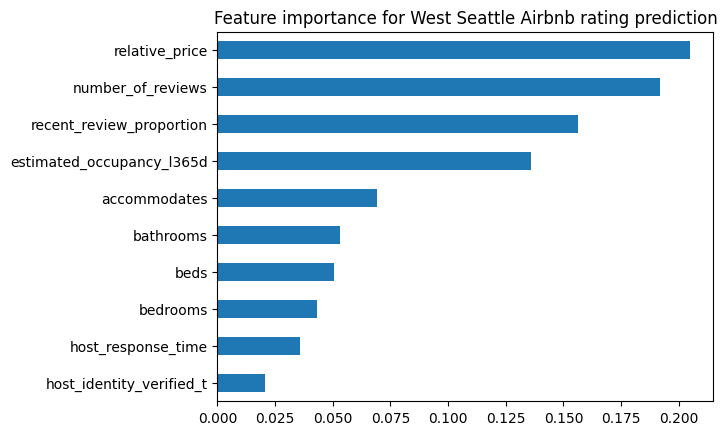

In [100]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature importance for West Seattle Airbnb rating prediction")
plt.show()

### Ballard

In [101]:
# Ballard
df_ballard = df_clean[df_clean["neighbourhood_group_cleansed"] == "Ballard"]
df_ballard = df_ballard.drop(columns=["neighbourhood_group_cleansed"])

In [102]:
df_ballard['review_scores_rating'].describe()

count    362.000000
mean       4.509779
std        1.318423
min        0.000000
25%        4.840000
50%        4.940000
75%        4.997500
max        5.000000
Name: review_scores_rating, dtype: float64

In [103]:
## target variable (review_scores_rating) : high score (1) vs. low score (0) (threshold: 50% quartile)
threshold = 4.94

df_ballard['review_scores_class'] = (df_ballard["review_scores_rating"] > threshold).astype(int)
df_ballard = df_ballard.drop(columns=["review_scores_rating"])

In [104]:
## run RF model

X = df_ballard.drop(columns=["review_scores_class"])
y = df_ballard["review_scores_class"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [105]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6027397260273972
[[26 11]
 [18 18]]
              precision    recall  f1-score   support

           0       0.59      0.70      0.64        37
           1       0.62      0.50      0.55        36

    accuracy                           0.60        73
   macro avg       0.61      0.60      0.60        73
weighted avg       0.61      0.60      0.60        73



In [106]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

relative_price               0.201325
number_of_reviews            0.199581
recent_review_proportion     0.198495
estimated_occupancy_l365d    0.121917
accommodates                 0.058474
bathrooms                    0.047942
beds                         0.041125
bedrooms                     0.038585
host_response_time           0.030476
is_long_term                 0.023282
host_identity_verified_t     0.013958
room_type_Private room       0.013776
host_identity_verified_f     0.011063
dtype: float64

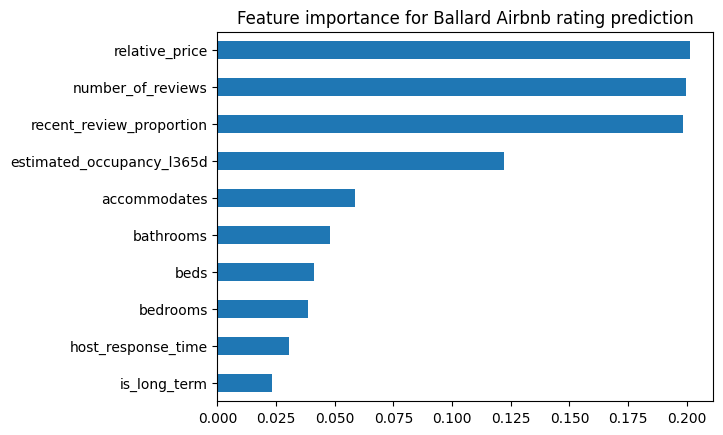

In [107]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature importance for Ballard Airbnb rating prediction")
plt.show()

### Cascade

In [108]:
# Cascade
df_cascade = df_clean[df_clean["neighbourhood_group_cleansed"] == "Cascade"]
df_cascade = df_cascade.drop(columns=["neighbourhood_group_cleansed"])

In [109]:
df_cascade['review_scores_rating'].describe()

count    244.00000
mean       2.67918
std        2.35132
min        0.00000
25%        0.00000
50%        4.00000
75%        4.90000
max        5.00000
Name: review_scores_rating, dtype: float64

In [110]:
## target variable (review_scores_rating) : high score (1) vs. low score (0) (threshold: 50% quartile)
threshold = 4

df_cascade['review_scores_class'] = (df_cascade["review_scores_rating"] > threshold).astype(int)
df_cascade = df_cascade.drop(columns=["review_scores_rating"])

In [111]:
## run RF model

X = df_cascade.drop(columns=["review_scores_class"])
y = df_cascade["review_scores_class"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [112]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9387755102040817
[[26  2]
 [ 1 20]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        28
           1       0.91      0.95      0.93        21

    accuracy                           0.94        49
   macro avg       0.94      0.94      0.94        49
weighted avg       0.94      0.94      0.94        49



In [113]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)

number_of_reviews            0.304250
recent_review_proportion     0.243786
estimated_occupancy_l365d    0.147646
relative_price               0.127949
is_long_term                 0.065345
room_type_Private room       0.031756
bedrooms                     0.023814
beds                         0.017390
accommodates                 0.016597
host_response_time           0.011113
bathrooms                    0.005320
host_identity_verified_t     0.004098
host_identity_verified_f     0.000593
room_type_Shared room        0.000343
dtype: float64

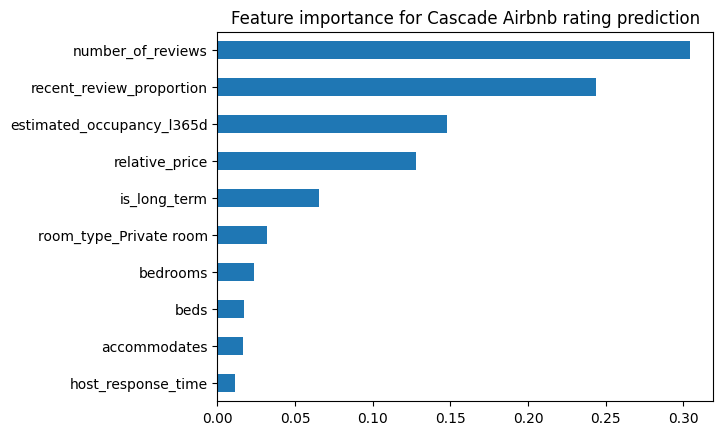

In [114]:
importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature importance for Cascade Airbnb rating prediction")
plt.show()

### Seattle (Prediction of rating score excluding neighborhood)

In [115]:
# Seattle
df_seattle = df_clean.drop(columns=["neighbourhood_group_cleansed"])
df_seattle['review_scores_rating'].describe()

count    6072.000000
mean        4.249020
std         1.574278
min         0.000000
25%         4.670000
50%         4.880000
75%         4.970000
max         5.000000
Name: review_scores_rating, dtype: float64

In [116]:
## target variable (review_scores_rating) : high score (1) vs. low score (0) (threshold: 50% quartile)
threshold = 4.88

df_seattle['review_scores_class'] = (df_seattle["review_scores_rating"] > threshold).astype(int)
df_seattle = df_seattle.drop(columns=["review_scores_rating"])

In [ ]:
## run RF model

X = df_seattle.drop(columns=["review_scores_class"])
y = df_cascad["review_scores_class"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)